In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import os
import json
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [5]:
df = pd.read_csv("/content/drive/MyDrive/SN_d_tot_V2.0.csv")
df

,1818;01;01;1818.001; -1; -1.0; 0;1
0,1818;01;02;1818.004; -1; -1.0; 0;1
1,1818;01;03;1818.007; -1; -1.0; 0;1
2,1818;01;04;1818.010; -1; -1.0; 0;1
3,1818;01;05;1818.012; -1; -1.0; 0;1
4,1818;01;06;1818.015; -1; -1.0; 0;1
...,...
75996,2026;01;27;2026.073; 98; 25.2; 13;0
75997,2026;01;28;2026.075; 119; 23.0; 15;0
75998,2026;01;29;2026.078; 93; 16.4; 19;0
75999,2026;01;30;2026.081; 85; 18.7; 19;0


In [6]:
columns = ['Year', 'Month', 'Day', 'Fractional_Year', 'Sunspot_Number', 'Standard_Deviation', 'Observations', 'Definitive']
df = pd.read_csv("/content/drive/MyDrive/SN_d_tot_V2.0.csv",sep=';',header=None,names=columns)

In [7]:
df

,Year,Month,Day,Fractional_Year,Sunspot_Number,Standard_Deviation,Observations,Definitive
0,1818,1,1,1818.001,-1,-1.0,0,1
1,1818,1,2,1818.004,-1,-1.0,0,1
2,1818,1,3,1818.007,-1,-1.0,0,1
3,1818,1,4,1818.010,-1,-1.0,0,1
4,1818,1,5,1818.012,-1,-1.0,0,1
...,...,...,...,...,...,...,...,...
75997,2026,1,27,2026.073,98,25.2,13,0
75998,2026,1,28,2026.075,119,23.0,15,0
75999,2026,1,29,2026.078,93,16.4,19,0
76000,2026,1,30,2026.081,85,18.7,19,0


In [8]:
df['Date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])
df.set_index('Date', inplace=True)

In [9]:
df.shape

(76002, 8)

In [10]:
df.isnull().sum()

,0
Year,0
Month,0
Day,0
Fractional_Year,0
Sunspot_Number,0
Standard_Deviation,0
Observations,0
Definitive,0


In [11]:
len(df[df['Sunspot_Number'] == -1 ])

3247

In [12]:
df['Sunspot_Number'].replace(-1,np.nan,inplace=True)

/tmp/ipython-input-787216730.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Sunspot_Number'].replace(-1,np.nan,inplace=True)


In [13]:
df.isnull().sum()

,0
Year,0
Month,0
Day,0
Fractional_Year,0
Sunspot_Number,3247
Standard_Deviation,0
Observations,0
Definitive,0


In [14]:
df.dropna(inplace=True)

In [15]:
df.isnull().sum()

,0
Year,0
Month,0
Day,0
Fractional_Year,0
Sunspot_Number,0
Standard_Deviation,0
Observations,0
Definitive,0


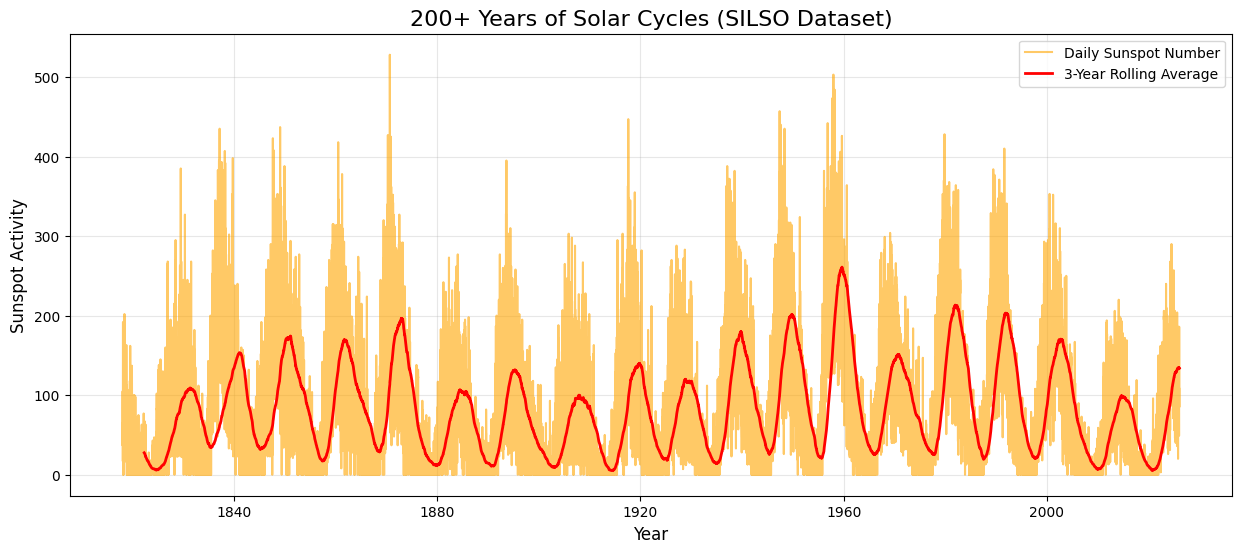

In [23]:
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['Sunspot_Number'], color='orange', alpha=0.6, label='Daily Sunspot Number')
plt.plot(df.index, df['Sunspot_Number'].rolling(window=365*3).mean(), color='red', linewidth=2, label='3-Year Rolling Average')
plt.title("200+ Years of Solar Cycles (SILSO Dataset)", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Sunspot Activity", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [24]:
df_data = df[['Sunspot_Number']].copy()
df_data['Smoothed'] = df_data['Sunspot_Number'].rolling(window=30).mean()
df_data.dropna(inplace=True)


In [25]:
df_data

,Sunspot_Number,Smoothed
Date,,
1818-03-20,0.0,40.400000
1818-03-21,85.0,41.066667
1818-03-23,52.0,41.566667
1818-03-24,80.0,41.666667
1818-03-27,57.0,40.300000
...,...,...
2026-01-27,98.0,117.166667
2026-01-28,119.0,116.300000
2026-01-29,93.0,114.633333


In [26]:
FUTURE_HORIZON = 365 * 5
SOLAR_CYCLE_DAYS = 4015

short_term_lags = [7, 30, 90, 180, 365]

historical_cycle_lags = [SOLAR_CYCLE_DAYS * i for i in range(1, 11)]

all_lags = short_term_lags + historical_cycle_lags

In [27]:
for lag in all_lags:
    df_data[f'Lag_{lag}'] = df_data['Smoothed'].shift(lag)

df_data['Target_Future'] = df_data['Smoothed'].shift(-FUTURE_HORIZON)

ml_df = df_data.dropna()

feature_cols = [f'Lag_{lag}' for lag in all_lags] + ['Smoothed']
X = ml_df[feature_cols].values
y = ml_df['Target_Future'].values

In [28]:
split_idx = int(0.8 * len(X))
X_train, y_train = X[:split_idx], y[:split_idx]
X_test, y_test = X[split_idx:], y[split_idx:]

In [29]:
model = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, n_jobs=-1, random_state=42)

In [30]:
predictions_test = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions_test)
print(f"Model Mean Absolute Error: {mae:.2f} sunspots")

Model Mean Absolute Error: 82.17 sunspots


In [31]:
historical_horizon = 365 * 5
past_5_years_data = df_data['Sunspot_Number'].iloc[-historical_horizon:].values
max_historical = df_data['Sunspot_Number'].max()

historical_threat_levels = (past_5_years_data / max_historical).clip(0, 1) * 100

historical_export = []
for i in range(historical_horizon):
    day_offset = -historical_horizon + i # Negative days represent the past
    threat = float(historical_threat_levels[i])
    historical_export.append({
        "day_offset": day_offset,
        "threat_level": threat,
        "projected_flare_class": "X" if threat > 80 else ("M" if threat > 50 else ("C" if threat > 20 else "A/B")),
        "is_historical": True
    })

In [33]:
last_known_data = df_data.iloc[-1].copy()
future_predictions = []

for i in range(FUTURE_HORIZON):
    current_features_list = [last_known_data.get(f'Lag_{lag}', 0) for lag in all_lags] + [last_known_data['Smoothed']]
    current_features = np.array([current_features_list])

    pred_val = model.predict(current_features)[0]
    future_predictions.append(pred_val)

    for j in range(len(all_lags)-1, 0, -1):
        last_known_data[f'Lag_{all_lags[j]}'] = last_known_data[f'Lag_{all_lags[j-1]}']

    last_known_data[f'Lag_{all_lags[0]}'] = last_known_data['Smoothed']
    last_known_data['Smoothed'] = pred_val

future_threat_levels = (np.array(future_predictions) / max_historical).clip(0, 1) * 100

future_export = []
for i in range(FUTURE_HORIZON):
    threat = float(future_threat_levels[i])
    future_export.append({
        "day_offset": int(i),
        "threat_level": threat,
        "projected_flare_class": "X" if threat > 80 else ("M" if threat > 50 else ("C" if threat > 20 else "A/B")),
        "is_historical": False
    })

In [34]:
full_timeline = historical_export + future_export

prediction_data = {
    "timeline_length": len(full_timeline),
    "predictions": full_timeline
}

with open("prediction_5yr.json", "w") as f:
    json.dump(prediction_data, f, indent=2)

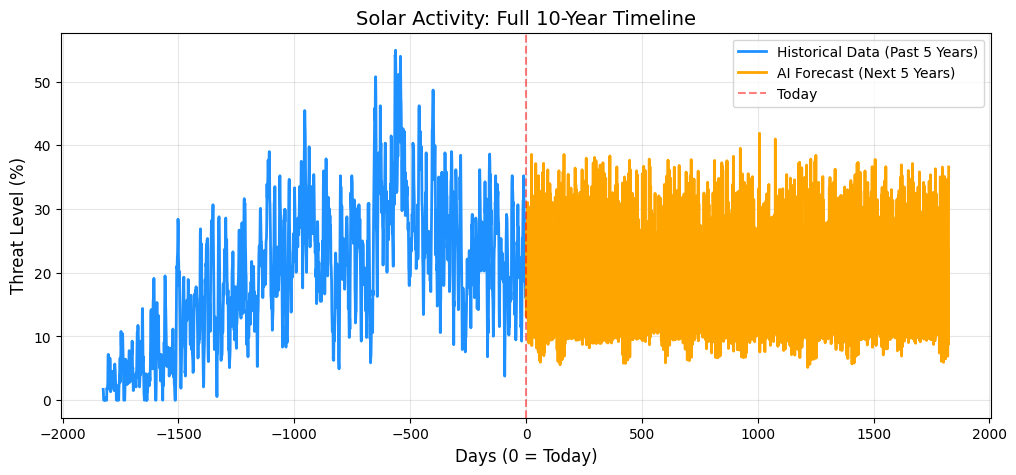

In [36]:
plt.figure(figsize=(12, 5))
plt.plot(range(-historical_horizon, 0), historical_threat_levels, color='dodgerblue', linewidth=2, label='Historical Data (Past 5 Years)')
plt.plot(range(0, FUTURE_HORIZON), future_threat_levels, color='orange', linewidth=2, label='AI Forecast (Next 5 Years)')
plt.title("Solar Activity: Full 10-Year Timeline", fontsize=14)
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Today')
plt.xlabel("Days (0 = Today)", fontsize=12)
plt.ylabel("Threat Level (%)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()